# Sensitivity Analysis 

## Methodology

I use Morris screening (Morris, 1991) to identify which input parameters most strongly influence three model outputs at 2050. Morris is a global, derivative-free method that is cheap to run — each parameter gets ranked by its mean absolute elementary effect (μ\*) and standard deviation (σ), without requiring the thousands of samples that variance-based methods like Sobol need.

**How it works:**
1. I define a parameter space (ranges) for each analysis
2. SALib generates a set of parameter combinations using the Morris one-at-a-time (OAT) sampling design
3. I run the full model for each combination and record the output of interest
4. SALib computes μ\* (overall influence) and σ (nonlinearity / interaction strength) for each parameter
5. Parameters with high μ\* are important; parameters with high σ relative to μ\* have nonlinear or interaction effects

**Three separate analyses are run:**
- **Iridium inflow (t/yr at 2050):** dominated by PEMWE-related parameters (market share, stack lifetime, iridium intensity) and H-DRI scale
- **Nickel inflow (kt/yr at 2050):** dominated by AEC-related parameters (market share, stack lifetime, nickel intensity) and H-DRI scale
- **CO₂ emissions (Mt/yr at 2050):** dominated by steel production route mix (BF-BOF share, H-DRI share), grid decarbonisation speed, and steel intensity

**Reading the plots:**
- Horizontal bar chart: ranks parameters by μ\* — longer bar = more influential
- μ\*–σ scatter plot: points near the diagonal (σ ≈ μ\*) indicate nonlinear or interaction effects; points far below the diagonal indicate near-linear, non-interactive effects

N = 100 trajectories per analysis. Random seed fixed at 42 for reproducibility.

In [ ]:
import sys
sys.path.append('..')
from model_functions import run_scenario
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from SALib.sample import morris as morris_sample
from SALib.analyze import morris as morris_analyze
from SALib.plotting.morris import horizontal_bar_plot, covariance_plot

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
})

processed_root = Path.cwd().parent / 'data' / 'processed'
folders = {
    'iridium':   processed_root / 'iridium',
    'nickel':    processed_root / 'nickel',
    'emissions': processed_root / 'emissions',
}
for folder in folders.values():
    folder.mkdir(parents=True, exist_ok=True)

In [35]:
# ── Iridium sensitivity ───────────────────────────────────────────────────────
problem_ir = {
    'num_vars': 6,
    'names': [
        'H-DRI Share',
        'PEMWE Market Share',
        'PEMWE Stack Lifetime',
        'Scrap Recycling Rate',
        'Iridium Intensity',
        'Steel Intensity',
    ],
    'bounds': [
        [0.10, 1.00],    # dri_share_2050
        [0.20, 0.44],    # pem_share (capped so other_share = 1-0.55-pem >= 0.01)
        [65500, 105000], # lifetime_PEM (hours)
        [0.85, 0.95],    # scrap_end
        [0.03,  0.30],   # iridium_intensity_2050 (g/kW)
        [6,     14],     # L (t/cap)
    ]
}

In [ ]:
np.random.seed(42)
param_values_ir = morris_sample.sample(problem_ir, N=100, optimal_trajectories=None)

IDX_2050 = np.where(np.arange(2022, 2101) == 2050)[0][0]

baseline_ir = {
    'k_scen':                 0.07,
    'scrap_end':              0.85,
    'grid_co2':               'current_policies',
    'eaf_efficiency':         470,
    'aec_share':              0.55,
    'other_share':            0.10,
    'h2_conversion':          54,
    'lifetime_AEC':           90000,
    'lifetime_Other':         45000,
    'efficiency_AEC':         50.0,
    'efficiency_PEM':         55.0,
    'efficiency_Other':       43.4,
    'nickel_intensity':       800,
    'platinum_intensity_2022': 0.45,
    'platinum_intensity_2030': 0.25,
    'platinum_intensity_2050': 0.25,
    'iridium_intensity_2022': 0.55,
    'iridium_intensity_2030': 0.30,
}

Y_ir = np.zeros(len(param_values_ir))
for i, sample in enumerate(param_values_ir):
    p = baseline_ir.copy()
    p['dri_share_2050']         = sample[0]
    p['pem_share']              = sample[1]
    p['other_share']            = 1 - 0.55 - sample[1]
    p['lifetime_PEM']           = sample[2]
    p['scrap_end']              = sample[3]
    p['iridium_intensity_2050'] = sample[4]
    p['L']                      = sample[5]
    sc = run_scenario(p, f'morris_ir_{i}', verbose=False, output_folder=folders['iridium'])
    Y_ir[i] = sc['materials']['iridium_inflow'][IDX_2050] * 1000

print('Iridium done.')

C:\Users\ovid\AppData\Local\Temp\ipykernel_13388\2106177075.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap      = plt.cm.get_cmap('tab20', len(all_names))


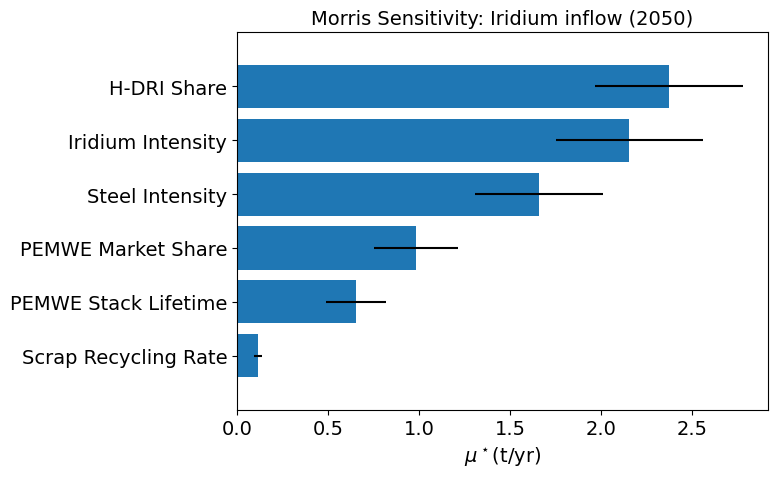

In [36]:
colors = plt.cm.tab10.colors
all_names = sorted(set(problem_ir['names']) | set(problem_ni['names']) | set(problem_co2['names']))
cmap      = plt.cm.get_cmap('tab20', len(all_names))
color_map = {name: cmap(i) for i, name in enumerate(all_names)}

Si_ir = morris_analyze.analyze(problem_ir, param_values_ir, Y_ir, print_to_console=False)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
horizontal_bar_plot(ax, Si_ir, unit='(t/yr)')
ax.set_title('Morris Sensitivity: Iridium inflow (2050)')
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
for i, (name, mu, sigma) in enumerate(zip(problem_ir['names'], Si_ir['mu_star'], Si_ir['sigma'])):
    ax.scatter(mu, sigma, s=60, color=color_map[name], zorder=3, label=name)

lim = max(Si_ir['mu_star'].max(), Si_ir['sigma'].max()) * 1.1
ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, alpha=0.5, label=r'$\sigma = \mu^*$')
ax.set_xlabel(r'$\mu^*$ (mean absolute effect)', fontsize=15)
ax.set_ylabel(r'$\sigma$ (standard deviation)', fontsize=15)
ax.set_title('Morris Sensitivity: Iridium inflow at 2050 (t/yr)')
ax.legend(fontsize=14)
ax.grid(alpha=0.2)
plt.tight_layout()
#fig.savefig('../visualizations/sensitivity/iridium_scatter_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## Nickel Sensitivity

In [26]:
# ── Nickel sensitivity ────────────────────────────────────────────────────────
problem_ni = {
    'num_vars': 6,
    'names': ['H-DRI Share', 'Scrap End', 'Steel Intensity', 
              'Nickel Intensity', 'AWE Stack Lifetime', 'AWE Market Share'],
    'bounds': [
        [0.10, 1.00],   # dri_share_2050
        [0.85, 0.95],   # scrap_end
        [6, 14],        # L
        [400, 1200],    # nickel_intensity
        [80000, 101500],# lifetime_AEC
        [0.20, 0.70],   # aec_share
    ]
}

In [ ]:
IDX_2050 = np.where(np.arange(2022, 2101) == 2050)[0][0]

np.random.seed(42)
param_values_ni = morris_sample.sample(problem_ni, N=100, optimal_trajectories=None)

baseline_ni = {
    'k_scen':                 0.07,
    'scrap_end':              0.85,
    'grid_co2':               'current_policies',
    'eaf_efficiency':         470,
    'aec_share':              0.55,
    'pem_share':              0.35,
    'other_share':            0.10,
    'lifetime_AEC':           90000,
    'lifetime_PEM':           85000,
    'lifetime_Other':         45000,
    'efficiency_AEC':         50.0,
    'efficiency_PEM':         55.0,
    'efficiency_Other':       43.4,
    'nickel_intensity':       800,
    'platinum_intensity_2022': 0.45,
    'platinum_intensity_2030': 0.25,
    'platinum_intensity_2050': 0.25,
    'iridium_intensity_2022': 0.55,
    'iridium_intensity_2030': 0.30,
    'iridium_intensity_2050': 0.30,
    'dri_share_2050':         0.10,
    'h2_conversion':          54,
    'L':                      11.3,
}


Y_ni = np.zeros(len(param_values_ni))
for i, sample in enumerate(param_values_ni):
    p = baseline_ni.copy()
    p['dri_share_2050']   = sample[0]
    p['scrap_end']        = sample[1]
    p['L']                = sample[2]
    p['nickel_intensity'] = sample[3]
    p['lifetime_AEC']     = sample[4]
    p['aec_share']        = sample[5]
    p['other_share']      = 1 - sample[5] - 0.20
    sc = run_scenario(p, f'morris_ni_{i}', verbose=False, output_folder=folders['nickel'])
    Y_ni[i] = sc['materials']['nickel_inflow'][IDX_2050]

print('Nickel done.')

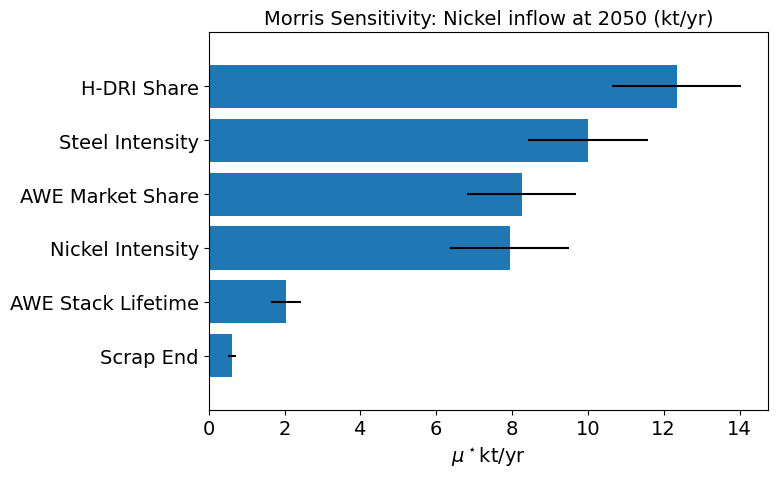

In [28]:
Si_ni = morris_analyze.analyze(problem_ni, param_values_ni, Y_ni, print_to_console=False)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
horizontal_bar_plot(ax, Si_ni, unit='kt/yr')
ax.set_title('Morris Sensitivity: Nickel inflow at 2050 (kt/yr)')
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
for i, (name, mu, sigma) in enumerate(zip(problem_ni['names'], Si_ni['mu_star'], Si_ni['sigma'])):
    ax.scatter(mu, sigma, s=60, color=color_map[name], zorder=3, label=name)

lim = max(Si_ni['mu_star'].max(), Si_ni['sigma'].max()) * 1.1
ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, alpha=0.5, label=r'$\sigma = \mu^*$')
ax.set_xlabel(r'$\mu^*$ (mean absolute effect)', fontsize=15)
ax.set_ylabel(r'$\sigma$ (standard deviation)', fontsize=15)
ax.set_title('Morris Sensitivity: Nickel inflow at 2050 (kt/yr)')
ax.legend(fontsize=14)
ax.grid(alpha=0.2)
plt.tight_layout()
#fig.savefig('../visualizations/sensitivity/nickel_scatter_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## CO₂ Emissions Sensitivity

In [ ]:
problem_co2 = {
    'num_vars': 5,
    'names': [
        'Steel Intensity',
        'DRI Share',
        'BF-BOF Share',
        'Grid CO2 Intensity',
        'EAF Efficiency',
    ],
    'bounds': [
        [6,    14],    # L — steel intensity saturation (t/cap)
        [0.00, 0.60],  # dri_share_2050 — H-DRI share of total steel
        [0.01, 0.60],  # bfbof_share_2050 — BF-BOF share of total steel
        [0,    192],   # grid_co2 — grid CO2 intensity at 2050 (g/kWh)
        [310,  470],   # eaf_efficiency — EAF electricity consumption (kWh/t)
    ]
}

np.random.seed(42)
param_values_co2 = morris_sample.sample(problem_co2, N=100, optimal_trajectories=None)

baseline_co2 = {
    'k_scen':                 0.07,
    'scrap_end':              0.85,
    'grid_co2':               'current_policies',
    'eaf_efficiency':         470,
    'dri_share_2050':         0.15,
    'bfbof_share_2050':       0.40,
    'bf_emission_factor':     2.3,      
    'aec_share':              0.55,
    'pem_share':              0.35,     
    'other_share':            0.10,     
    'lifetime_AEC':           90000,
    'lifetime_PEM':           70000,    
    'lifetime_Other':         45000,
    'efficiency_AEC':         50.0,
    'efficiency_PEM':         55.0,
    'efficiency_Other':       43.4,
    'h2_conversion':          54,      
    'nickel_intensity':       800,
    'platinum_intensity_2022': 0.45,
    'platinum_intensity_2030': 0.25,
    'platinum_intensity_2050': 0.25,
    'iridium_intensity_2022': 0.55,
    'iridium_intensity_2030': 0.30,
    'iridium_intensity_2050': 0.30,     
    'L':                      11.3,
}


IDX_2050 = np.where(np.arange(2022, 2101) == 2050)[0][0]

Y_co2 = np.zeros(len(param_values_co2))
for i, sample in enumerate(param_values_co2):
    p = baseline_co2.copy()
    p['L']                  = sample[0]
    p['dri_share_2050']     = sample[1]
    p['bfbof_share_2050']   = sample[2]
    p['grid_co2']           = sample[3]
    p['eaf_efficiency']     = sample[4]
    sc = run_scenario(p, f'morris_co2_{i}', verbose=False, output_folder=folders['emissions'])
    Y_co2[i] = sc['emissions']['Total Emissions'][IDX_2050]

print('CO2 done.')

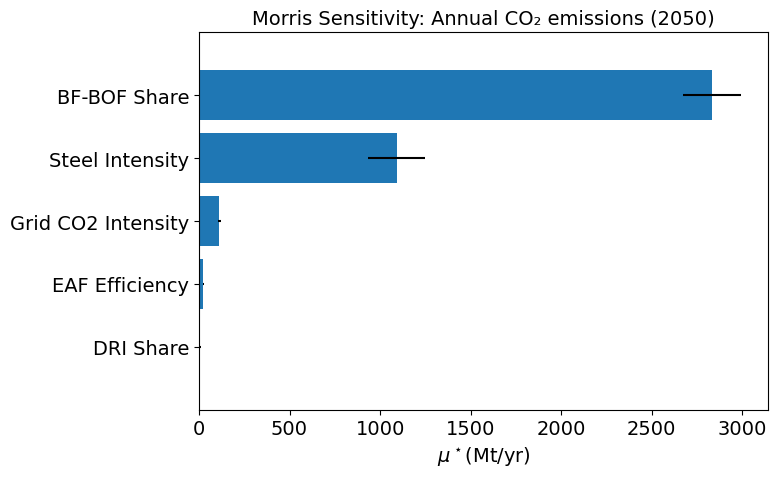

In [33]:
Si_co2 = morris_analyze.analyze(problem_co2, param_values_co2, Y_co2, print_to_console=False)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
horizontal_bar_plot(ax, Si_co2, unit='(Mt/yr)')
ax.set_title('Morris Sensitivity: Annual CO₂ emissions (2050)')
plt.tight_layout()
plt.show()

In [ ]:
colors = plt.cm.tab10.colors
all_names = sorted(set(problem_ir['names']) | set(problem_ni['names']) | set(problem_co2['names']))
cmap      = plt.cm.get_cmap('tab20', len(all_names))
color_map = {name: cmap(i) for i, name in enumerate(all_names)}

fig, ax = plt.subplots(figsize=(8, 7))
for i, (name, mu, sigma) in enumerate(zip(problem_co2['names'], Si_co2['mu_star'], Si_co2['sigma'])):
    ax.scatter(mu, sigma, s=60, color=color_map[name], zorder=3, label=name)

lim = max(Si_co2['mu_star'].max(), Si_co2['sigma'].max()) * 1.1
ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, alpha=0.5, label=r'$\sigma = \mu^*$')
ax.set_xlabel(r'$\mu^*$ (mean absolute effect)', fontsize=15)
ax.set_ylabel(r'$\sigma$ (standard deviation)', fontsize=15)
ax.set_title(r'Morris Sensitivity: Annual CO$_2$ emissions at 2050 (Mt/yr)')
ax.legend(fontsize=12)
ax.grid(alpha=0.2)
plt.tight_layout()
#fig.savefig('../visualizations/sensitivity/emissions_scatter_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()